# Pytorch Profiler

In [2]:
from torch.profiler import profile, ProfilerActivity, schedule, record_function

In [2]:
!nvidia-smi

Tue Apr 14 12:30:39 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090 Ti     On  | 00000000:41:00.0 Off |                  Off |
| 30%   32C    P8              27W / 450W |     14MiB / 24564MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [3]:
device = "cuda:0"

## Pytorch profiling with Perfetto Trace Visualizer

`skip_first` + `repeat` * [`wait` (no tracing) + `warmup` (tracing, but not recording) + `active` (recording)]

[Perfetto trace visualizer](https://ui.perfetto.dev)

In [9]:
import torch
from segmentation_models_pytorch import Unet as SMPUnet


class CustomWeightsModel:
    def load_encoder_weights(self, weights_path: str) -> None:
        state_dict = torch.load(weights_path, map_location='cpu')

        if isinstance(state_dict, dict):
            if 'state_dict' in state_dict:
                state_dict = state_dict['state_dict']
            elif 'model' in state_dict:
                state_dict = state_dict['model']
        try:
            self.encoder.load_state_dict(state_dict, strict=False)
        except Exception as e:
            raise RuntimeError(
                f'Не удалось загрузить веса из файла {weights_path}: {e}'
            )


class Unet(SMPUnet, CustomWeightsModel):
    """
    Кастомная реализация UNet с загрузкой весов энкодера из файла.
    """

    def __init__(
        self,
        encoder_name: str = 'efficientnet-b4',
        encoder_depth: int = 5,
        encoder_weights: str | None = None,
        decoder_use_batchnorm: bool = True,
        decoder_channels: list[int] = [256, 128, 64, 32, 16],
        in_channels: int = 3,
        classes: int = 10,
        activation: str | None = None,
        aux_params: dict | None = None,
        **kwargs,
    ):
        super().__init__(
            encoder_name=encoder_name,
            encoder_depth=encoder_depth,
            encoder_weights=None,
            decoder_use_batchnorm=decoder_use_batchnorm,
            decoder_channels=decoder_channels,
            decoder_attention_type=decoder_attention_type,
            in_channels=in_channels,
            classes=classes,
            activation=activation,
            aux_params=aux_params,
            **kwargs,
        )

        if encoder_weights is not None:
            self.load_encoder_weights(encoder_weights)

model = Unet(encoder_weights='./weights/efficientnet-b4.pth')
model.eval().to(device)
model

Веса загружены вручную


Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          48, 48, kernel_size=(3, 3), stride=[1, 1], groups=48, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          48, 12, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          12, 48, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Ident

In [13]:
example_tensor = torch.ones(
    (1, 3, 512, 512),
    dtype=torch.float32,
    device=device,
)

In [6]:
from tqdm.auto import trange


with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=schedule(
        skip_first=1,
        wait=1,
        warmup=3,
        active=2,
        repeat=1,
    ),
    record_shapes=True,
#     on_trace_ready=on_trace_ready,
) as prof:
    with torch.no_grad():
        for _ in trange(7):
            pred = model(example_tensor)
            prof.step()

            
prof.export_chrome_trace("native_model.json")
print(prof.key_averages().table(sort_by='cpu_time_total'))

 71%|███████████████████████████████████████████████████████████████████████████████████████▏                                  | 5/7 [00:00<00:00, 14.41it/s]STAGE:2026-04-14 12:51:29 4147533:4147533 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2026-04-14 12:51:29 4147533:4147533 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-04-14 12:51:29 4147533:4147533 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00,  7.29it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*        23.96%      13.118ms        99.28%      54.353ms      27.177ms       0.000us         0.00%      16.666ms       8.333ms             2  
                                           aten::conv2d         1.75%     958.000us        32.20%      17.627ms      44.739us       0.000us         0.00%       7.750ms      19.670us           394  
         

Рассмотрим стартовый блок - свертка + батчнорм + активацию

```
(_conv_stem): Conv2dStaticSamePadding(
      3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
```

Изначально состоит из
  - padding
  - conv2d
  - batchnorm
  - silu

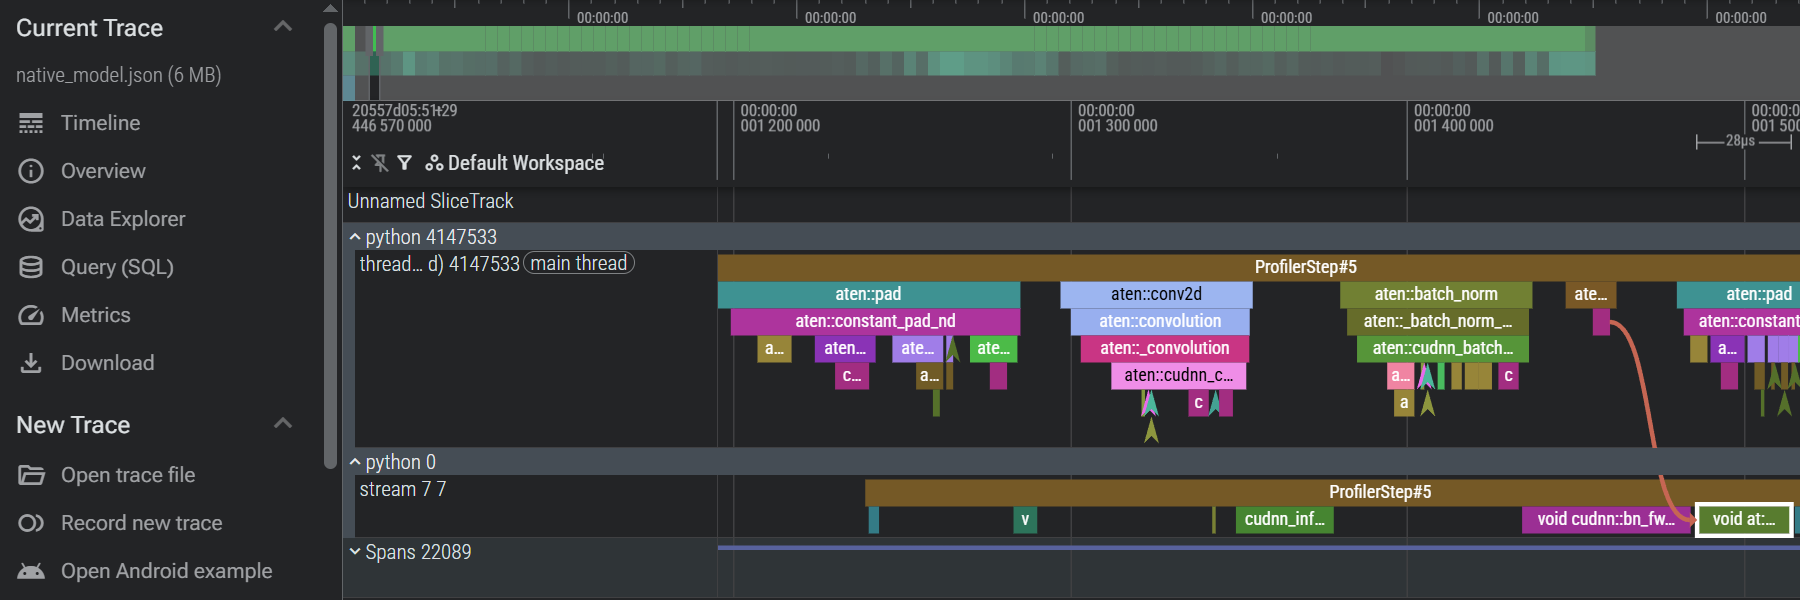

### torch.jit.trace

In [7]:
model_trace = torch.jit.trace(
    model,
    example_inputs=example_tensor,
)

model_trace.eval()
model_trace(example_tensor)
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=schedule(
        skip_first=1,
        wait=1,
        warmup=3,
        active=2,
        repeat=1,
    ),
    record_shapes=True,
#     on_trace_ready=on_trace_ready,
) as prof:
    with torch.no_grad():
        for _ in trange(7):
            pred = model_trace(example_tensor)
            prof.step()

            
prof.export_chrome_trace("traced_model.json")
print(prof.key_averages().table(sort_by='cpu_time_total'))

  0%|                                                                                                                                  | 0/7 [00:00<?, ?it/s]STAGE:2026-04-14 12:52:33 4147533:4147533 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2026-04-14 12:52:33 4147533:4147533 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-04-14 12:52:33 4147533:4147533 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 21.38it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.56%     163.000us        97.75%      28.281ms      14.140ms       0.000us         0.00%      14.259ms       7.130ms             2  
                                                forward         9.09%       2.631ms        97.19%      28.118ms      14.059ms       0.000us         0.00%      14.259ms       7.130ms             2  
         

После трассировки состоит из
  - padding
  - conv2d
  - batchnorm + silu

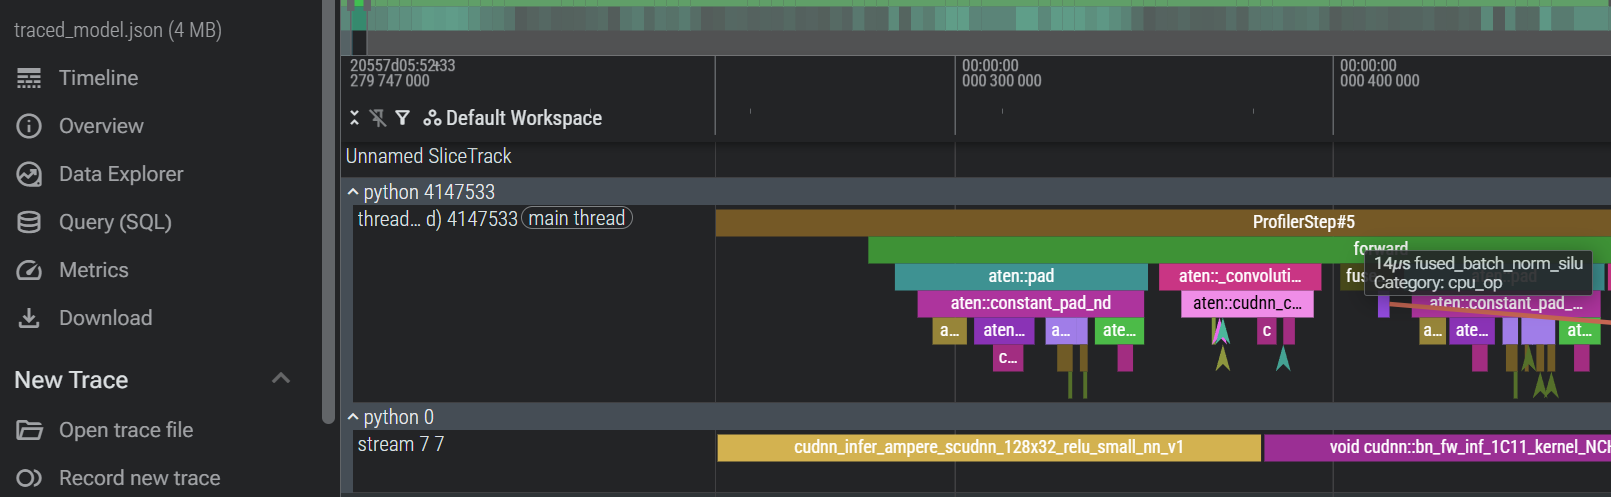

### optimize_for_inference

In [8]:
optimized_model = torch.jit.optimize_for_inference(model_trace)
optimized_model.eval()

optimized_model(example_tensor)
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=schedule(
        skip_first=1,
        wait=1,
        warmup=3,
        active=2,
        repeat=1,
    ),
    record_shapes=True,
#     on_trace_ready=on_trace_ready,
) as prof:
    with torch.no_grad():
        for _ in trange(7):
            pred = optimized_model(example_tensor)
            prof.step()

            
prof.export_chrome_trace("optimized_model.json")
print(prof.key_averages().table(sort_by='cpu_time_total'))

 14%|█████████████████▍                                                                                                        | 1/7 [00:04<00:27,  4.58s/it]STAGE:2026-04-14 12:56:55 4147533:4147533 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2026-04-14 12:56:55 4147533:4147533 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-04-14 12:56:55 4147533:4147533 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:05<00:00,  1.34it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.45%     130.000us        98.56%      28.566ms      14.283ms       0.000us         0.00%      13.603ms       6.801ms             2  
                                                forward         6.36%       1.843ms        98.11%      28.436ms      14.218ms       0.000us         0.00%      13.603ms       6.801ms             2  
         

После оптимизации для инференса состоит из
  - padding
  - conv2d + add
  - silu
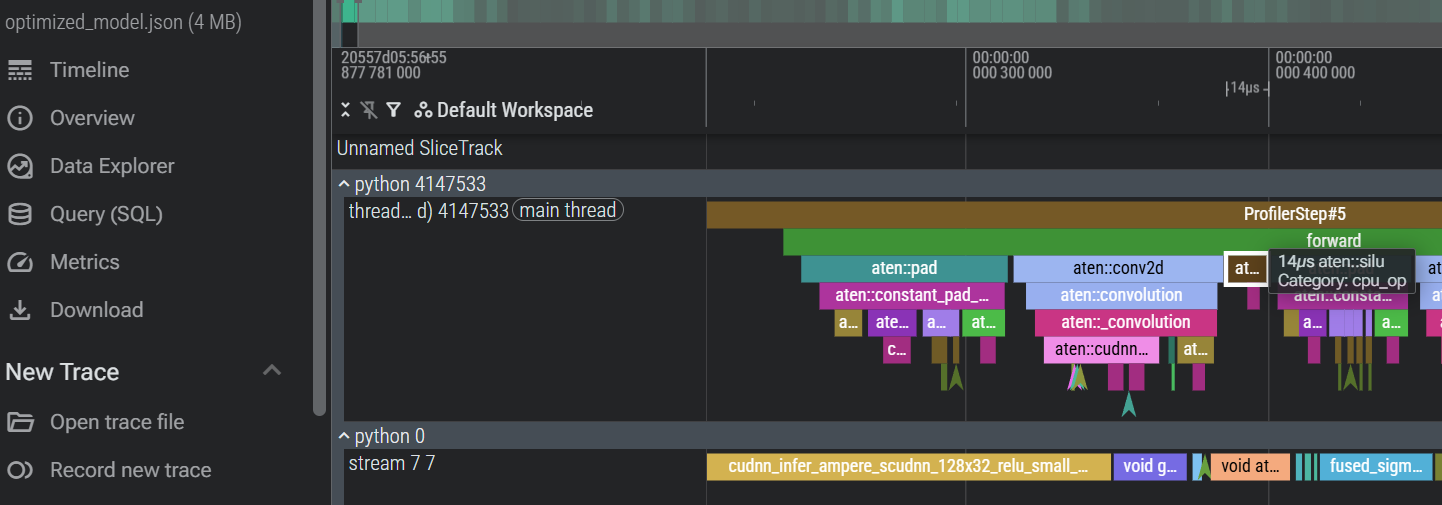

### torch.compile

In [11]:
compiled_model = torch.compile(model, mode="max-autotune")
compiled_model.eval()
compiled_model(example_tensor)

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=schedule(
        skip_first=1,
        wait=1,
        warmup=3,
        active=2,
        repeat=1,
    ),
    record_shapes=True,
#     on_trace_ready=on_trace_ready,
) as prof:
    with torch.no_grad():
        for _ in trange(7):
            pred = compiled_model(example_tensor)
            prof.step()

            
prof.export_chrome_trace("compiled_model.json")
print(prof.key_averages().table(sort_by='cpu_time_total'))

AUTOTUNE convolution(1x16x1x1, 256x16x1x1)
  triton_convolution_1528 0.0038 ms 100.0%
  triton_convolution_1530 0.0039 ms 96.7%
  conv1x1_via_mm 0.0040 ms 94.4%
  triton_convolution_1529 0.0041 ms 91.1%
  convolution 0.0042 ms 90.8%
  triton_convolution_1531 0.0045 ms 83.7%
  triton_convolution_1527 0.0048 ms 78.7%
SingleProcess AUTOTUNE takes 1.2220 seconds
AUTOTUNE convolution(1x256x32x32, 1x256x1x1)
  convolution 0.0059 ms 100.0%
  conv1x1_via_mm 0.0062 ms 95.3%
  triton_convolution_1536 0.0094 ms 62.8%
  triton_convolution_1535 0.0110 ms 53.6%
  triton_convolution_1532 0.0122 ms 48.3%
  triton_convolution_1537 0.0146 ms 40.4%
  triton_convolution_1533 0.0179 ms 33.0%
  triton_convolution_1534 0.0635 ms 9.3%
SingleProcess AUTOTUNE takes 2.0646 seconds
AUTOTUNE convolution(1x312x1x1, 19x312x1x1)
  conv1x1_via_mm 0.0068 ms 100.0%
  convolution 0.0068 ms 99.5%
  triton_convolution_1540 0.0086 ms 78.8%
  triton_convolution_1538 0.0113 ms 60.2%
  triton_convolution_1539 0.0130 ms 52.3%
S

AUTOTUNE convolution(1x32x1x1, 2x32x1x1)
  triton_convolution_1648 0.0037 ms 100.0%
  convolution 0.0039 ms 95.9%
  conv1x1_via_mm 0.0039 ms 95.9%
  triton_convolution_1646 0.0042 ms 87.9%
  triton_convolution_1647 0.0043 ms 86.6%
SingleProcess AUTOTUNE takes 0.8085 seconds
AUTOTUNE convolution(1x2x1x1, 32x2x1x1)
  triton_convolution_1650 0.0037 ms 100.0%
  triton_convolution_1649 0.0040 ms 92.0%
  conv1x1_via_mm 0.0042 ms 87.1%
  convolution 0.0046 ms 80.7%
SingleProcess AUTOTUNE takes 0.6134 seconds
AUTOTUNE convolution(1x32x256x256, 1x32x1x1)
  conv1x1_via_mm 0.0158 ms 100.0%
  triton_convolution_1655 0.0160 ms 98.5%
  convolution 0.0160 ms 98.3%
  triton_convolution_1651 0.0161 ms 98.1%
  triton_convolution_1654 0.0165 ms 95.6%
  triton_convolution_1656 0.0165 ms 95.4%
  triton_convolution_1652 0.0172 ms 91.9%
  triton_convolution_1653 0.0200 ms 78.9%
SingleProcess AUTOTUNE takes 1.8644 seconds
AUTOTUNE convolution(1x32x512x512, 16x32x3x3)
  triton_convolution_1657 0.1683 ms 100.0%

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         1.37%     621.000us        99.97%      45.431ms      22.715ms       0.000us         0.00%      10.644ms       5.322ms             2  
                                  Torch-Compiled Region        50.77%      23.072ms        98.56%      44.790ms      22.395ms       0.000us         0.00%      10.644ms       5.322ms             2  
         

После компиляции состоит из
  - padding triton_poi_fused_constant_pad_nd_convolution_1
  - conv sm80_xmma_fprop_implicit_gemm_indexed_wo_smem_tf32f32_tf32f32_f32_nhwckrsc_nhwc_tilesize128x16x32_stage1_warpsize4x1x1_g1_tensor16x8x8_aligna4_alignc4_execute_kernel_cudnn_infer
  - batch_norm triton_poi_fused__native_batch_norm_legit_no_training_2
  - silu (вместе со след pad) triton_poi_fused_constant_pad_nd_silu_3
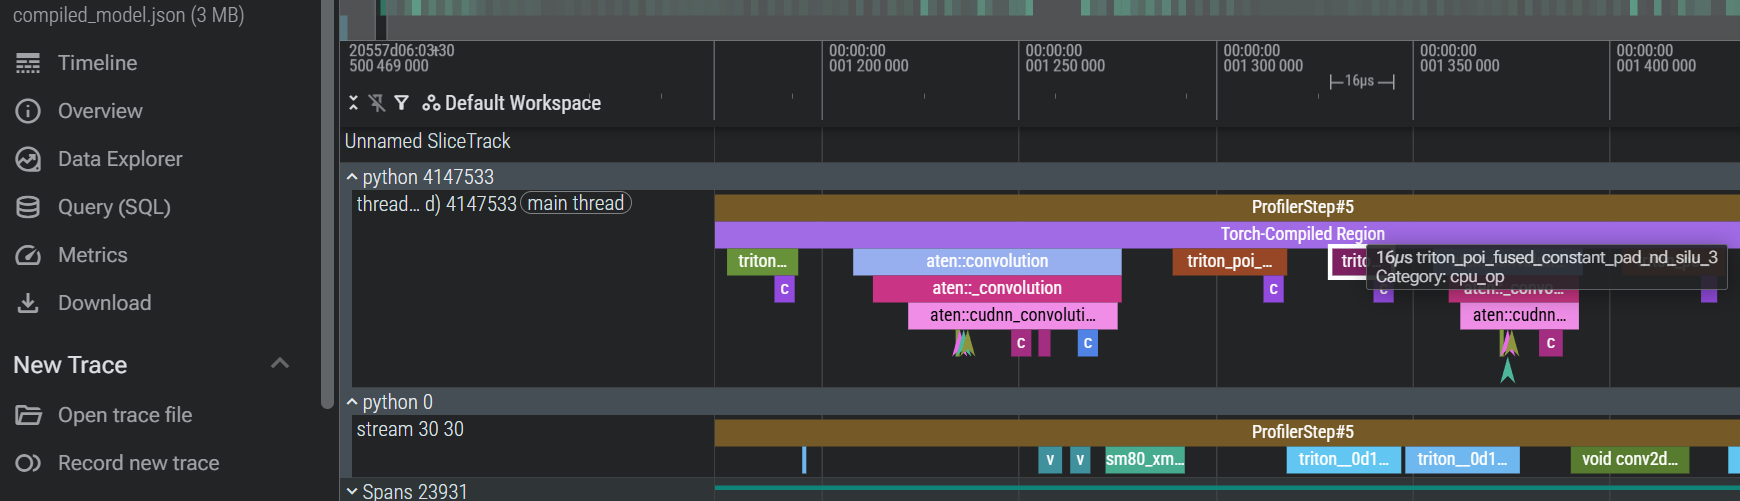